# 08 — Training-seed uncertainty
Refit the three frequentist specifications across independent initialization seeds. The data split, projected calibration directions, data order, and forecast random numbers are held fixed. This isolates initialization/optimization variability and combines it with serial sampling uncertainty through a hierarchical seed–moving-block bootstrap.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import CARNNConfig, TrainingConfig
from innovcal.evaluation import paired_seed_block_bootstrap
from innovcal.experiments import run_frequentist_seed_comparison
OUT = ROOT / 'results' / 'seed_uncertainty'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
returns = pd.read_csv(ROOT / 'data' / 'processed' / 'financial_returns.csv', index_col=0, parse_dates=True)
returns = returns[['AAPL', 'JPM', 'XOM', 'WMT']].dropna().sort_index()
assert returns.index.is_monotonic_increasing and not returns.index.has_duplicates
TRAINING_SEEDS = [611, 619, 631, 641, 647, 653, 661, 673, 683, 691]
print(f'{len(returns)} observations; {len(TRAINING_SEEDS)} seeds × 3 models = {3 * len(TRAINING_SEEDS)} fits')

4779 observations; 10 seeds × 3 models = 30 fits


## Fit the matched repetitions
This is the expensive cell. Ten seeds are the primary specification. For a pipeline check only, temporarily use the first two seeds, but restore all ten before interpreting results.

In [3]:
training = TrainingConfig(epochs=200, batch_size=64, patience=25, seed=606, selection_metric='nll')
result = run_frequentist_seed_comparison(
    returns.to_numpy(), TRAINING_SEEDS,
    model_config=CARNNConfig(input_dim=4, hidden_dim=32),
    training_config=training, lambda_cal=100.0, lambda_seq=2000.0,
    projection_seed=606, forecast_seed=20_606, n_forecast_samples=500,
)
display(result.metrics.groupby('model').agg(['mean', 'std']))

training_seed            best_epoch                rmse  \
                           mean        std       mean       std      mean   
model                                                                       
CA-RNN                    651.0  26.566478       42.5  7.199537  0.947351   
CA-RNN sequential         651.0  26.566478       42.2  7.036413  0.944797   
RNN                       651.0  26.566478       32.5  9.834746  0.936801   

                            energy_score            coverage            ...  \
                        std         mean       std      mean       std  ...   
model                                                                   ...   
CA-RNN             0.001852     1.151041  0.002104  0.865021  0.005562  ...   
CA-RNN sequential  0.002005     1.147753  0.002472  0.874813  0.005934  ...   
RNN                0.001233     1.139414  0.001486  0.872545  0.005714  ...   

                  pit_mean_absolute_autocorrelation           pit_mean_ks  \
                                               mean       std        mean   
model                                                                       
CA-RNN                                     0.038347  0.001439    0.056438   
CA-RNN sequential                          0.037195  0.000961    0.055705   
RNN                                        0.030558  0.000807    0.059491   

                            coordinate_pit_calibration_error            \
                        std                             mean       std   
model                                                                    
CA-RNN             0.002144                         0.001431  0.000133   
CA-RNN sequential  0.002049                         0.001462  0.000118   
RNN                0.001359                         0.001743  0.000130   

                  coordinate_pit_mean_absolute_autocorrelation            \
                                                          mean       std   
model                                                                      
CA-RNN                                                0.035318  0.001582   
CA-RNN sequential                                     0.035966  0.000846   
RNN                                                   0.029405  0.001537   

                  coordinate_pit_mean_ks            
                                    mean       std  
model                                               
CA-RNN                          0.062407  0.003601  
CA-RNN sequential               0.065588  0.003672  
RNN                             0.070417  0.003327  

[3 rows x 26 columns]

In [4]:
result.metrics.to_csv(OUT / 'seed_metrics.csv', index=False)
payload = {'target': result.target, 'projections': result.projections, 'training_seeds': np.asarray(TRAINING_SEEDS)}
manifest = []
for index, (name, samples) in enumerate(result.forecast_samples.items()):
    key = f'samples_{index}'
    payload[key] = samples
    manifest.append({'model': name, 'array_key': key})
np.savez_compressed(OUT / 'seed_forecasts.npz', **payload)
pd.DataFrame(manifest).to_csv(OUT / 'seed_forecast_manifest.csv', index=False)
print('Saved metrics and retained forecasts; later cells can be rerun without refitting.')

Saved metrics and retained forecasts; later cells can be rerun without refitting.


In [5]:
COMPARISONS = [('CA-RNN', 'RNN'), ('CA-RNN sequential', 'CA-RNN'), ('CA-RNN sequential', 'RNN')]
inference = paired_seed_block_bootstrap(
    result.target, result.forecast_samples, COMPARISONS, result.projections,
    block_length=20, n_bootstrap=2000, confidence=0.95, seed=808,
)
display(inference)
inference.to_csv(OUT / 'hierarchical_seed_block_bootstrap.csv', index=False)

,n_seeds,n_origins,block_length,n_bootstrap,candidate,comparator,metric,difference,bootstrap_se,ci_lower,ci_upper,probability_difference_below_zero
0,10,937,20,2000,CA-RNN,RNN,mean_squared_error,0.019880,0.001705,0.016697,0.023445,0.0000
1,10,937,20,2000,CA-RNN,RNN,energy_score,0.011626,0.000868,0.009867,0.013267,0.0000
2,10,937,20,2000,CA-RNN,RNN,interval_score,0.046972,0.007361,0.031938,0.061061,0.0000
3,10,937,20,2000,CA-RNN,RNN,interval_width,-0.006828,0.012036,-0.028566,0.018157,0.7245
4,10,937,20,2000,CA-RNN,RNN,coverage,-0.007524,0.001626,-0.010673,-0.004348,1.0000
5,10,937,20,2000,CA-RNN,RNN,coverage_error,0.007524,0.001626,0.004348,0.010673,0.0000
6,10,937,20,2000,CA-RNN,RNN,pit_calibration_error,-0.000117,0.000046,-0.000239,-0.000057,0.9990
7,10,937,20,2000,CA-RNN,RNN,pit_mean_absolute_autocorrelation,0.007790,0.001374,0.000430,0.005750,0.0115
8,10,937,20,2000,CA-RNN sequential,CA-RNN,mean_squared_error,-0.004832,0.000752,-0.006158,-0.003165,1.0000
9,10,937,20,2000,CA-RNN sequential,CA-RNN,energy_score,-0.003288,0.000482,-0.004101,-0.002220,1.0000


In [6]:
loss_metrics = {'mean_squared_error', 'energy_score', 'interval_score', 'coverage_error', 'pit_calibration_error', 'pit_mean_absolute_autocorrelation'}
decisions = inference.assign(interval_excludes_zero=(inference.ci_lower > 0) | (inference.ci_upper < 0))
decisions['direction'] = 'descriptive'
is_loss = decisions.metric.isin(loss_metrics)
decisions.loc[is_loss & (decisions.ci_upper < 0), 'direction'] = 'candidate favored'
decisions.loc[is_loss & (decisions.ci_lower > 0), 'direction'] = 'comparator favored'
decisions.loc[is_loss & ~decisions.interval_excludes_zero, 'direction'] = 'unresolved'
display(decisions[['candidate', 'comparator', 'metric', 'difference', 'ci_lower', 'ci_upper', 'direction']])
decisions.to_csv(OUT / 'hierarchical_decisions.csv', index=False)

,candidate,comparator,metric,difference,ci_lower,ci_upper,direction
0,CA-RNN,RNN,mean_squared_error,0.019880,0.016697,0.023445,comparator favored
1,CA-RNN,RNN,energy_score,0.011626,0.009867,0.013267,comparator favored
2,CA-RNN,RNN,interval_score,0.046972,0.031938,0.061061,comparator favored
3,CA-RNN,RNN,interval_width,-0.006828,-0.028566,0.018157,descriptive
4,CA-RNN,RNN,coverage,-0.007524,-0.010673,-0.004348,descriptive
5,CA-RNN,RNN,coverage_error,0.007524,0.004348,0.010673,comparator favored
6,CA-RNN,RNN,pit_calibration_error,-0.000117,-0.000239,-0.000057,candidate favored
7,CA-RNN,RNN,pit_mean_absolute_autocorrelation,0.007790,0.000430,0.005750,comparator favored
8,CA-RNN sequential,CA-RNN,mean_squared_error,-0.004832,-0.006158,-0.003165,candidate favored
9,CA-RNN sequential,CA-RNN,energy_score,-0.003288,-0.004101,-0.002220,candidate favored


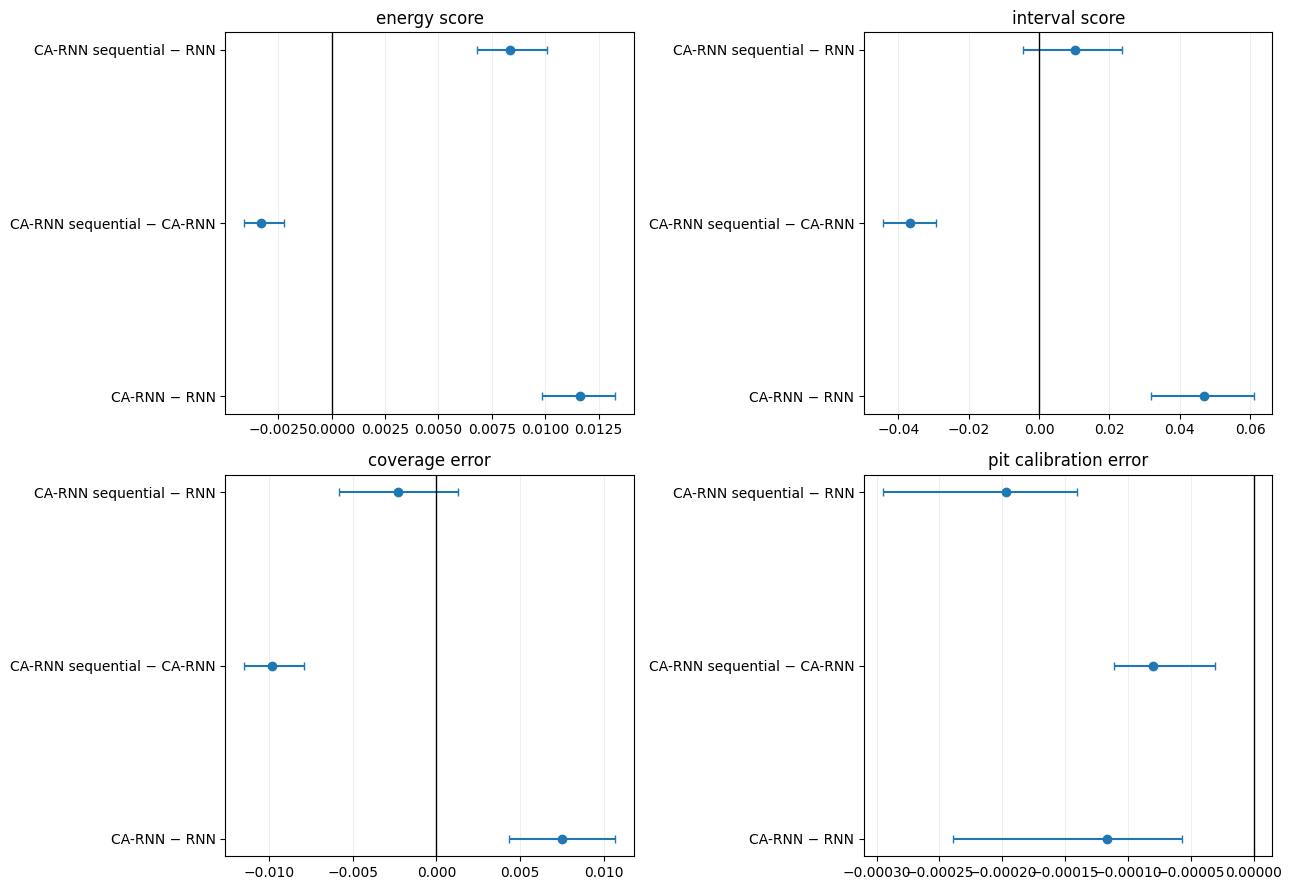

In [7]:
shown = ['energy_score', 'interval_score', 'coverage_error', 'pit_calibration_error']
figure_data = inference[inference.metric.isin(shown)].copy()
figure_data['comparison'] = figure_data.candidate + ' − ' + figure_data.comparator
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, metric in zip(axes.flat, shown):
    subset = figure_data[figure_data.metric.eq(metric)].reset_index(drop=True)
    axis.errorbar(subset.difference, range(len(subset)), xerr=[subset.difference-subset.ci_lower, subset.ci_upper-subset.difference], fmt='o', capsize=3)
    axis.axvline(0, color='black', linewidth=1)
    axis.set_yticks(range(len(subset)), subset.comparison)
    axis.set_title(metric.replace('_', ' ')); axis.grid(axis='x', alpha=.2)
plt.tight_layout()
fig.savefig(OUT / 'hierarchical_intervals.png', dpi=180, bbox_inches='tight')

## Interpretation
The estimand is the average candidate-minus-comparator effect over the ten chosen optimization seeds and the observed financial test period. Negative differences favor the candidate for loss metrics. Raw coverage and interval width are descriptive; coverage error is distance from 90%. A hierarchical interval containing zero is unresolved, not evidence of equality. This experiment addresses initialization and serial sampling variability, but it still conditions on one market split, architecture, and hyperparameter-development path.